In [1]:
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    mean_squared_error,
    r2_score,
)
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDRegressor

RNG_SEED = 5215
rng = np.random.default_rng(RNG_SEED)

# Keep output clean: some BLAS backends emit RuntimeWarnings from internal matmul
warnings.filterwarnings(
    'ignore',
    category=RuntimeWarning,
    message=r'.*encountered in matmul.*',
)

print('Environment ready')

Environment ready


• n+1= 0,3,6,9 → Random Forest Algorithm.
• n+1= 1,4,7→ Support Vector Machine.
• n+1= 2,5,8→ Time Series.

In [ ]:

student_login_id = 'es09305'  # <-- change this to your own

def last_digit_from_id(login_id: str) -> int:
    login_id = (login_id or '').strip()
    if not login_id:
        raise ValueError('Empty login ID. Please enter your student login ID.')
    digits = [ch for ch in login_id if ch.isdigit()]
    if not digits:
        raise ValueError('No digits found in login ID; cannot compute n.')
    return int(digits[-1])

def choose_assignment_3_method(n: int) -> str:
    k = (n + 1) % 10
    if k in {0, 3, 6, 9}:
        return 'random_forest'
    if k in {1, 4, 7}:
        return 'svm'
    if k in {2, 5, 8}:
        return 'time_series'
    raise RuntimeError('Mapping failed; check the n+1 rule.')

n = last_digit_from_id(student_login_id)
k = (n + 1) % 10
chosen_method = choose_assignment_3_method(n)

print('Login ID:', student_login_id)
print('n (last digit):', n)
print('(n+1) mod 10:', k)
print('Chosen method:', chosen_method)

Login ID: es09305
n (last digit): 5
(n+1) mod 10: 6
Chosen method: random_forest


In [4]:
def expected_method_by_digit(d: int) -> str:
    k = (d + 1) % 10
    if k in {0, 3, 6, 9}:
        return 'random_forest'
    if k in {1, 4, 7}:
        return 'svm'
    return 'time_series'

table = []
for d in range(10):
    got = choose_assignment_3_method(d)
    exp = expected_method_by_digit(d)
    table.append({'n': d, '(n+1)%10': (d+1)%10, 'expected': exp, 'got': got, 'ok': got == exp})

check = pd.DataFrame(table)
assert check['ok'].all(), 'Mapping test failed for at least one digit.'

print('All mapping tests passed.')
check

All mapping tests passed.


,n,(n+1)%10,expected,got,ok
0,0,1,svm,svm,True
1,1,2,time_series,time_series,True
2,2,3,random_forest,random_forest,True
3,3,4,svm,svm,True
4,4,5,time_series,time_series,True
5,5,6,random_forest,random_forest,True
6,6,7,svm,svm,True
7,7,8,time_series,time_series,True
8,8,9,random_forest,random_forest,True
9,9,0,random_forest,random_forest,True


In [5]:
BIG_N = 250_000
P = 50
TEST_FRAC = 0.2

def make_big_classification(n_rows: int, n_features: int, seed: int):
    X_arr, y_arr = make_classification(
        n_samples=n_rows,
        n_features=n_features,
        n_informative=max(10, n_features // 2),
        n_redundant=n_features // 6,
        n_repeated=0,
        n_classes=2,
        weights=[0.6, 0.4],
        flip_y=0.015,
        class_sep=1.0,
        random_state=seed,
    )
    return X_arr.astype(np.float32), y_arr.astype(np.int64)

def make_time_series(length: int, seed: int):
    r = np.random.default_rng(seed)
    t = np.arange(length, dtype=np.float32)
    trend = 0.0004 * t
    yearly = 0.8 * np.sin(2 * np.pi * t / 365.0)
    weekly = 0.35 * np.sin(2 * np.pi * t / 7.0)
    noise = r.normal(0.0, 0.35, size=length).astype(np.float32)

    # light AR(1) structure for realism
    ar = np.zeros(length, dtype=np.float32)
    phi = 0.6
    for i in range(1, length):
        ar[i] = phi * ar[i - 1] + noise[i]

    series = 10.0 + trend + yearly + weekly + ar
    return series

if chosen_method in {'random_forest', 'svm'}:
    X_big, y_big = make_big_classification(BIG_N, P, seed=RNG_SEED)
    feature_names = [f'f_{i:02d}' for i in range(P)]
    frame_X = pd.DataFrame(X_big, columns=feature_names)
    target_y = pd.Series(y_big, name='y')
    print('X shape:', frame_X.shape)
    print('y balance:', target_y.value_counts(normalize=True).round(4).to_dict())

else:
    TS_LEN = 300_000
    LAGS = 24
    s = make_time_series(TS_LEN, seed=RNG_SEED)
    base = pd.DataFrame({'value': s})
    for lag in range(1, LAGS + 1):
        base[f'lag_{lag:02d}'] = base['value'].shift(lag)
    base['roll_mean_12'] = base['value'].shift(1).rolling(12).mean()
    base['y_next'] = base['value'].shift(-1)
    base = base.dropna().reset_index(drop=True)

    frame_X = base.drop(columns=['value', 'y_next'])
    target_y = base['y_next']
    print('Time series table:', frame_X.shape)
    print('Target mean/std:', float(target_y.mean()), float(target_y.std()))

frame_X.head()

X shape: (250000, 50)
y balance: {0: 0.5985, 1: 0.4015}


,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,f_09,...,f_40,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49
0,0.277768,-0.659451,-0.810011,2.578233,-3.128664,-6.885370,-0.322903,-6.298346,-2.418083,-4.478676,...,-5.521301,1.168505,1.374640,-0.322613,0.730266,3.394672,-1.988363,0.325429,-0.218468,1.384395
1,0.322925,-1.684887,-0.825641,-3.779902,-5.480762,2.595687,1.092508,-2.117094,-2.807227,2.434598,...,-1.803424,1.517849,-0.239359,-0.676078,-0.475954,2.892911,-5.847487,-0.867172,4.730731,0.817536
2,-1.314779,-0.812532,-0.912058,-3.425672,2.964629,-1.837740,1.170399,0.026906,-2.913986,-6.687741,...,7.449200,0.085015,2.818631,-0.389311,1.136707,2.411151,2.418811,2.077653,-1.737442,0.400105
3,1.037690,-1.033588,4.015326,2.112460,6.712399,-2.155159,1.063256,2.082002,2.131959,-1.166804,...,0.191643,-0.374226,-5.173774,-0.124133,-0.098728,7.054630,5.980056,-0.230365,-4.259135,0.935961
4,-0.462223,0.544856,1.760474,0.697604,6.029976,0.082515,-1.001156,-3.704549,-0.847691,-1.311106,...,3.061947,-0.194209,-1.478220,-0.085017,-0.849506,1.657721,0.603431,-1.781659,1.399218,-1.168064


In [6]:
if chosen_method in {'random_forest', 'svm'}:
    X_train, X_test, y_train, y_test = train_test_split(
        frame_X, target_y, test_size=TEST_FRAC, random_state=RNG_SEED, stratify=target_y
    )
else:
    cut = int(len(frame_X) * (1.0 - TEST_FRAC))
    X_train, X_test = frame_X.iloc[:cut], frame_X.iloc[cut:]
    y_train, y_test = target_y.iloc[:cut], target_y.iloc[cut:]

print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (200000, 50) (200000,)
Test : (50000, 50) (50000,)


## 5) Train + evaluate the selected method

In [7]:
def show_confusion(cm, title='Confusion matrix'):
    plt.figure(figsize=(4.8, 3.9))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.tight_layout()
    plt.show()

def evaluate_classifier(model, X_te, y_te, label: str):
    pred = model.predict(X_te)
    acc = accuracy_score(y_te, pred)
    print(f'{label} accuracy: {acc:.4f}')
    print(classification_report(y_te, pred, digits=4))
    cm = confusion_matrix(y_te, pred)
    show_confusion(cm)

    auc = None
    if hasattr(model, 'decision_function'):
        score = model.decision_function(X_te)
        auc = roc_auc_score(y_te, score)
    elif hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, proba)

    if auc is not None:
        print(f'ROC-AUC: {auc:.4f}')
    return acc, auc

def evaluate_regression(model, X_te, y_te, label: str):
    pred = model.predict(X_te)
    rmse = math.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)
    print(f'{label} RMSE: {rmse:.4f}')
    print(f'{label} R^2 : {r2:.4f}')

    tail = min(800, len(pred))
    plt.figure(figsize=(6.2, 4.0))
    plt.plot(np.arange(tail), y_te.iloc[-tail:].to_numpy(), label='actual')
    plt.plot(np.arange(tail), pred[-tail:], label='pred')
    plt.title('Time series forecast (last points)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return rmse, r2

Training subset used: (120000, 50)
RandomForestClassifier accuracy: 0.9726
              precision    recall  f1-score   support

           0     0.9673    0.9876    0.9774     29927
           1     0.9810    0.9502    0.9654     20073

    accuracy                         0.9726     50000
   macro avg     0.9741    0.9689    0.9714     50000
weighted avg     0.9728    0.9726    0.9725     50000



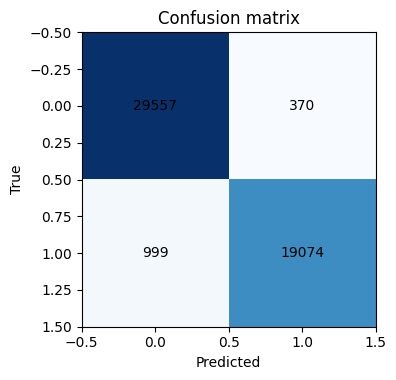

ROC-AUC: 0.9906
Done: RandomForestClassifier


In [8]:
model = None
model_label = None

if chosen_method == 'random_forest':
    # Random Forest on big data can be expensive; keep data big but cap training rows for runtime.
    TRAIN_CAP = 120_000
    if len(X_train) > TRAIN_CAP:
        take = rng.choice(len(X_train), size=TRAIN_CAP, replace=False)
        X_fit = X_train.iloc[take]
        y_fit = y_train.iloc[take]
        print('Training subset used:', X_fit.shape)
    else:
        X_fit, y_fit = X_train, y_train

    model = RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RNG_SEED,
    )
    model.fit(X_fit, y_fit)
    model_label = 'RandomForestClassifier'
    _ = evaluate_classifier(model, X_test, y_test, label=model_label)

elif chosen_method == 'svm':
    # A linear SVM scales better to large N than kernel SVM.
    model = Pipeline([
        ('scale', StandardScaler()),
        ('svm', LinearSVC(C=1.0, max_iter=4000, random_state=RNG_SEED)),
    ])
    model.fit(X_train, y_train)
    model_label = 'LinearSVC (scaled)'
    _ = evaluate_classifier(model, X_test, y_test, label=model_label)

elif chosen_method == 'time_series':
    # Forecast next value using lag features (chronological split already done).
    model = Pipeline([
        ('scale', StandardScaler()),
        ('sgd', SGDRegressor(
            loss='squared_error',
            penalty='l2',
            alpha=1e-4,
            max_iter=2000,
            tol=1e-3,
            random_state=RNG_SEED,
        )),
    ])
    model.fit(X_train, y_train)
    model_label = 'TimeSeries via SGDRegressor (lags)'
    _ = evaluate_regression(model, X_test, y_test, label=model_label)

else:
    raise RuntimeError('Unknown chosen_method')

print('Done:', model_label)